In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Path to the dataset (adjust if different)
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"

# Check if directory exists
if os.path.exists(source_dir):
    print("✅ Dataset found at:", source_dir)
else:
    print("❌ Dataset not found. Please check the path.")


✅ Dataset found at: /content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1


In [ ]:
dataset_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"


In [ ]:
import os

path = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"
print(os.listdir(path))


['River', 'Pasture', 'Industrial', 'SeaLake', 'Forest', 'PermanentCrop', 'Residential', 'Highway', 'HerbaceousVegetation', 'AnnualCrop']


In [ ]:
print(os.path.exists("/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"))


True


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Input preprocessed dataset
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_preprocessed1"
split_base = "/content/EuroSAT_full_split_3split"
train_dir = os.path.join(split_base, "train")
val_dir = os.path.join(split_base, "val")
test_dir = os.path.join(split_base, "test")

# Create output directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Get class names
classes = sorted(os.listdir(source_dir))

# Split images for each class
for cls in tqdm(classes, desc="Splitting Classes into Train/Val/Test"):
    cls_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # 70% train, 15% val, 15% test
    train_imgs, temp_imgs = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    # Create class folders
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    # Copy images
    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(train_dir, cls, img))
    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(val_dir, cls, img))
    for img in test_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(test_dir, cls, img))

print("✅ Train/Val/Test split completed at:", split_base)


Splitting Classes into Train/Val/Test: 100%|██████████| 10/10 [14:13<00:00, 85.38s/it]

✅ Train/Val/Test split completed at: /content/EuroSAT_full_split_3split


In [ ]:
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 886.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 36.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load and use the YOLOv8 classification model
model = YOLO('yolov8n-cls.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 5.31M/5.31M [00:00<00:00, 15.1MB/s]


In [ ]:
from ultralytics import YOLO

# Load the YOLOv8 classification model (nano version)
model = YOLO('yolov8n-cls.pt')

# Train directly using folders
model.train(
    data='/content/EuroSAT_full_split_3split',
    epochs=12,
    imgsz=224,
    project='runs/classify',
    name='forest_cls50',
    pretrained=True
)


Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/EuroSAT_full_split_3split, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=forest_cls50, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.

train: Scanning /content/EuroSAT_full_split_3split/train... 19006 images, 0 corrupt: 100%|██████████| 19006/19006 [00:11<00:00, 1622.50it/s]

train: New cache created: /content/EuroSAT_full_split_3split/train.cache


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4.3±1.0 MB/s, size: 3.5 KB)


val: Scanning /content/EuroSAT_full_split_3split/val... 4071 images, 0 corrupt: 100%|██████████| 4071/4071 [00:02<00:00, 1552.45it/s]


...

                   all      0.975          1



12 epochs completed in 3.600 hours.
Optimizer stripped from runs/classify/forest_cls50/weights/last.pt, 3.0MB
Optimizer stripped from runs/classify/forest_cls50/weights/best.pt, 3.0MB

Validating runs/classify/forest_cls50/weights/best.pt...
Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,447,690 parameters, 0 gradients, 3.3 GFLOPs
train: /content/EuroSAT_full_split_3split/train... found 19006 images in 10 classes ✅ 
val: /content/EuroSAT_full_split_3split/val... found 4071 images in 10 classes ✅ 
test: /content/EuroSAT_full_split_3split/test... found 4076 images in 10 classes ✅ 


               classes   top1_acc   top5_acc: 100%|██████████| 128/128 [00:58<00:00,  2.18it/s]


                   all      0.975          1
Speed: 0.0ms preprocess, 12.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/forest_cls50


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e7f3e2ed810>
curves: []
curves_results: []
fitness: 0.9873495399951935
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.974699079990387, 'metrics/accuracy_top5': 1.0, 'fitness': 0.9873495399951935}
save_dir: PosixPath('runs/classify/forest_cls50')
speed: {'preprocess': 0.0007679408038545706, 'inference': 12.468447148857638, 'loss': 4.682240293522987e-05, 'postprocess': 0.00010762343560158452}
task: 'classify'
top1: 0.974699079990387
top5: 1.0

In [ ]:
from ultralytics import YOLO

# Load best trained model
model = YOLO("runs/classify/forest_cls50/weights/best.pt")

# Evaluate on test split (no YAML required)
metrics = model.val(data="/content/EuroSAT_full_split_3split", split="test")

# Print nicely
top1 = metrics.results_dict['metrics/accuracy_top1']
top5 = metrics.results_dict['metrics/accuracy_top5']
fitness = metrics.fitness

print(f"📊 Final Evaluation:")
print(f"✅ Top-1 Accuracy : {top1 * 100:.2f}%")
print(f"✅ Top-5 Accuracy : {top5 * 100:.2f}%")
print(f"✅ Fitness Score  : {fitness:.4f}")


Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,447,690 parameters, 0 gradients, 3.3 GFLOPs
train: /content/EuroSAT_full_split_3split/train... found 19006 images in 10 classes ✅ 
val: /content/EuroSAT_full_split_3split/val... found 4071 images in 10 classes ✅ 
test: /content/EuroSAT_full_split_3split/test... found 4076 images in 10 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2.8±1.9 MB/s, size: 3.5 KB)


test: Scanning /content/EuroSAT_full_split_3split/test... 4076 images, 0 corrupt: 100%|██████████| 4076/4076 [00:02<00:00, 1435.65it/s]

test: New cache created: /content/EuroSAT_full_split_3split/test.cache



               classes   top1_acc   top5_acc: 100%|██████████| 255/255 [00:57<00:00,  4.46it/s]


                   all      0.975          1
Speed: 0.0ms preprocess, 12.2ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/val2
📊 Final Evaluation:
✅ Top-1 Accuracy : 97.52%
✅ Top-5 Accuracy : 100.00%
✅ Fitness Score  : 0.9876


In [ ]:
yaml_content = """
path: /content/EuroSAT_full_split_3split
train: train
val: val
test: test
nc: 10
names:
  - AnnualCrop
  - Forest
  - HerbaceousVegetation
  - Highway
  - Industrial
  - Pasture
  - PermanentCrop
  - Residential
  - River
  - SeaLake
"""

with open("eurosat_full.yaml", "w") as f:
    f.write(yaml_content)

print("✅ YAML file created: eurosat_full.yaml")


✅ YAML file created: eurosat_full.yaml


In [ ]:
model.val(data="eurosat_full.yaml", split="test")


Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 176.3±73.3 MB/s, size: 3.5 KB)


test: Scanning /content/EuroSAT_full_split_3split/test... 4076 images, 0 corrupt: 100%|██████████| 4076/4076 [00:00<?, ?it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 255/255 [00:56<00:00,  4.48it/s]


                   all      0.975          1
Speed: 0.0ms preprocess, 12.1ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/val3


ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e7f32380190>
curves: []
curves_results: []
fitness: 0.987610399723053
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.975220799446106, 'metrics/accuracy_top5': 1.0, 'fitness': 0.987610399723053}
save_dir: PosixPath('runs/classify/val3')
speed: {'preprocess': 0.0012733280170740082, 'inference': 12.101794404072361, 'loss': 9.731575324359693e-05, 'postprocess': 0.00020029809225198216}
task: 'classify'
top1: 0.975220799446106
top5: 1.0

In [ ]:
# Save the best model to your Google Drive
!cp "runs/classify/forest_cls50/weights/best.pt" "/content/drive/MyDrive/best_forest_model.pt"

print("✅ Model saved to Google Drive as: /MyDrive/best_forest_model.pt")


✅ Model saved to Google Drive as: /MyDrive/best_forest_model.pt


Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,447,690 parameters, 0 gradients, 3.3 GFLOPs
train: /content/EuroSAT_full_split_3split/train... found 19006 images in 10 classes ✅ 
val: /content/EuroSAT_full_split_3split/val... found 4071 images in 10 classes ✅ 
test: /content/EuroSAT_full_split_3split/test... found 4076 images in 10 classes ✅ 
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 180.2±74.5 MB/s, size: 3.5 KB)


test: Scanning /content/EuroSAT_full_split_3split/test... 4076 images, 0 corrupt: 100%|██████████| 4076/4076 [00:00<?, ?it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 255/255 [01:08<00:00,  3.75it/s]


                   all      0.975          1
Speed: 0.0ms preprocess, 14.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs/classify/val5


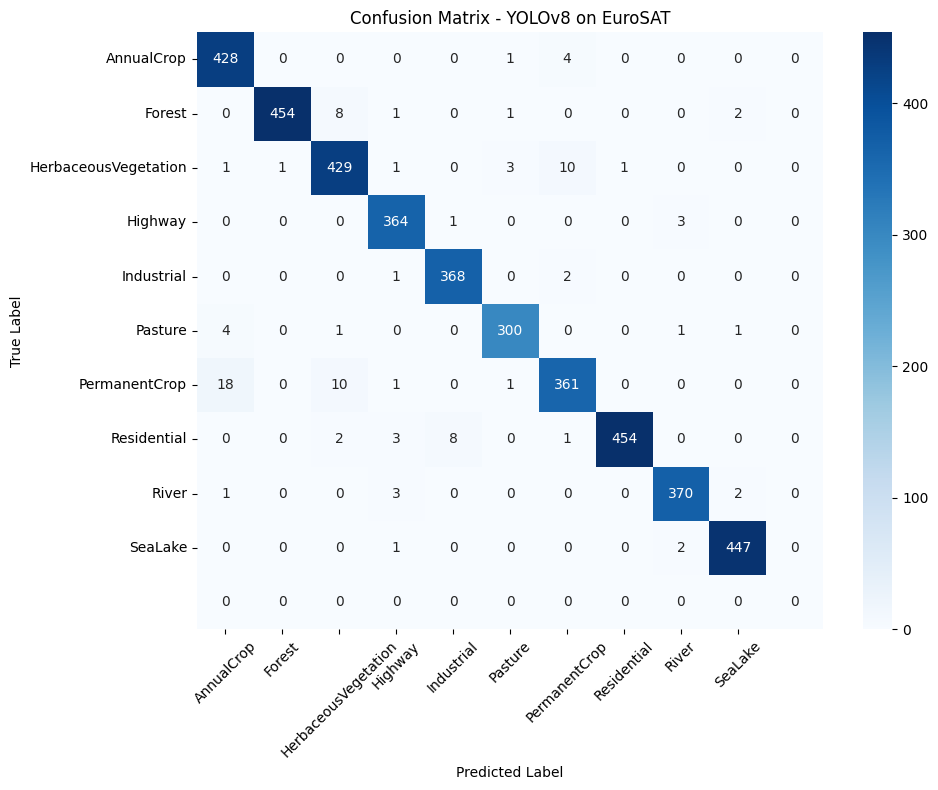

✅ Confusion matrix saved to: /MyDrive/confusion_matrix_forest_cls50.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report
from ultralytics import YOLO

# Load the model
model = YOLO("runs/classify/forest_cls50/weights/best.pt")

# Evaluate on test set
metrics = model.val(data="/content/EuroSAT_full_split_3split", split="test")

# Manually define EuroSAT class names
class_names = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway", "Industrial",
    "Pasture", "PermanentCrop", "Residential", "River", "SeaLake"
]

# Get confusion matrix
conf_mat = metrics.confusion_matrix.matrix.astype(int)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - YOLOv8 on EuroSAT")
plt.xticks(rotation=45)
plt.tight_layout()

# Save the plot
plt.savefig("/content/drive/MyDrive/confusion_matrix_forest_cls50.png", dpi=300)
plt.show()

print("✅ Confusion matrix saved to: /MyDrive/confusion_matrix_forest_cls50.png")


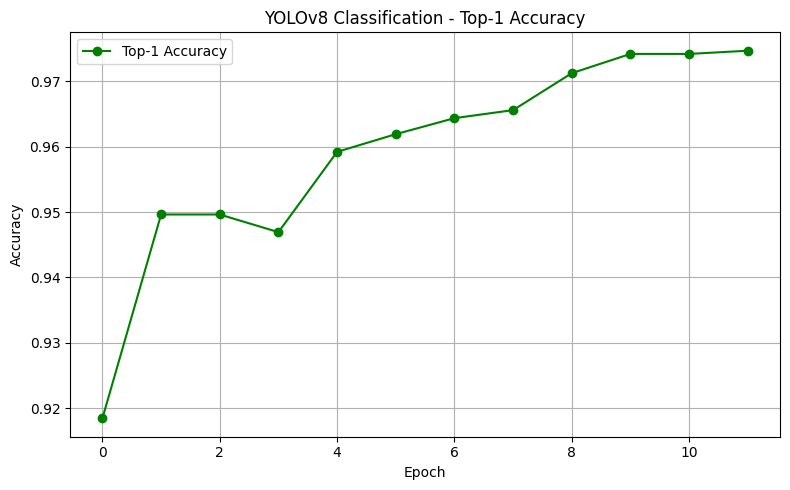

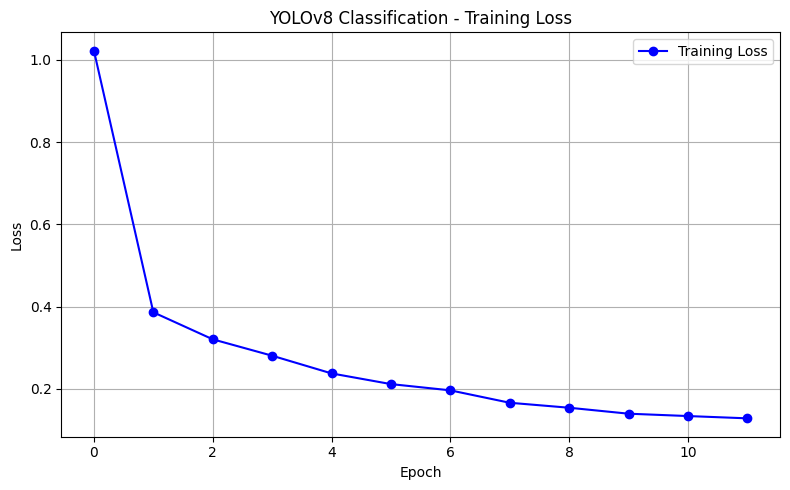

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and clean the results CSV
df = pd.read_csv("runs/classify/forest_cls50/results.csv")
df.columns = df.columns.str.strip()  # ✨ Fix hidden spaces

# Plot Top-1 Accuracy
plt.figure(figsize=(8, 5))
plt.plot(df["metrics/accuracy_top1"], marker='o', label="Top-1 Accuracy", color="green")
plt.title("YOLOv8 Classification - Top-1 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/forest_cls50_top1_accuracy.png", dpi=300)
plt.show()

# Plot Training Loss
plt.figure(figsize=(8, 5))
plt.plot(df["train/loss"], marker='o', label="Training Loss", color="blue")
plt.title("YOLOv8 Classification - Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/forest_cls50_train_loss.png", dpi=300)
plt.show()


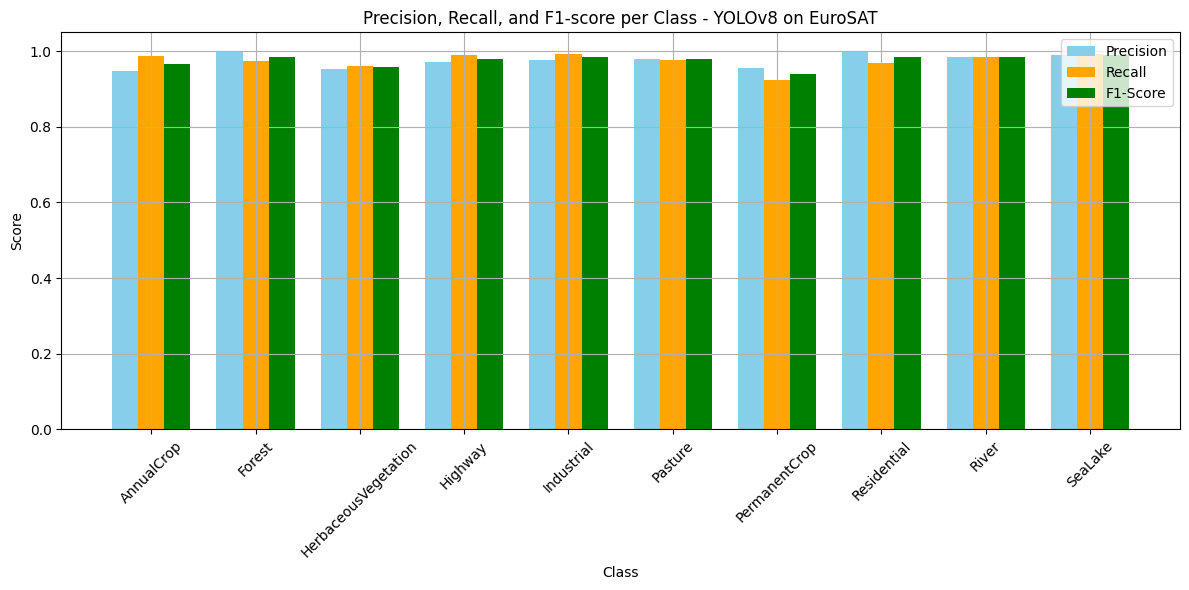

✅ Saved bar chart to: /MyDrive/forest_cls50_metrics_bars.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report

# Step 1: Get confusion matrix from YOLO metrics object
conf_mat = metrics.confusion_matrix.matrix.astype(int)

# Step 2: Manually define EuroSAT class names
class_names = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway", "Industrial",
    "Pasture", "PermanentCrop", "Residential", "River", "SeaLake"
]

# Step 3: Convert confusion matrix to y_true and y_pred lists
y_true, y_pred = [], []
for true_label in range(conf_mat.shape[0]):
    for pred_label in range(conf_mat.shape[1]):
        count = conf_mat[true_label][pred_label]
        y_true.extend([true_label] * count)
        y_pred.extend([pred_label] * count)

# Step 4: Generate classification report
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

# Step 5: Extract metrics
precision = [report[cls]['precision'] for cls in class_names]
recall = [report[cls]['recall'] for cls in class_names]
f1 = [report[cls]['f1-score'] for cls in class_names]

# Step 6: Plot the scores
x = np.arange(len(class_names))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, precision, width=width, label="Precision", color="skyblue")
plt.bar(x, recall, width=width, label="Recall", color="orange")
plt.bar(x + width, f1, width=width, label="F1-Score", color="green")

plt.xticks(x, class_names, rotation=45)
plt.ylim(0, 1.05)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1-score per Class - YOLOv8 on EuroSAT")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Step 7: Save the plot
plt.savefig("/content/drive/MyDrive/forest_cls50_metrics_bars.png", dpi=300)
plt.show()

print("✅ Saved bar chart to: /MyDrive/forest_cls50_metrics_bars.png")
